# Portal location parser

In [8]:
import json
import sys
from collections.abc import Iterator
from pathlib import Path

import matplotlib.pyplot as plt

# Make the library in ../src importable from this notebook.
SRC_DIR = Path.cwd().parent / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from portal_parser import find_portal_locations, save_portals  # noqa: E402

WORLD_DIR = Path.cwd().parent / 'saves' / 'ZipKrowd'  # Place your world save here
OUTPUT_PATH = Path.cwd().parent / 'output' / 'portals.json'

In [ ]:
# Scan the Overworld. coordinate_multiplier defaults to 1/8 (Overworld -> Nether
# scale); the Y coordinate is never scaled. Use seed for reproducible colors.
portals = find_portal_locations(
    WORLD_DIR,
    dimension='ow',
    coordinate_multiplier=1 / 8,
)

save_portals(portals, OUTPUT_PATH)
print(f'Found {len(portals)} portal(s) -> {OUTPUT_PATH}')

portals[:5]

Found 109 portal(s) -> \portals.json


[PortalLocation(name='0', description='', color='#f2cd88', x=5, z=2, y=65),
 PortalLocation(name='1', description='', color='#9ef288', x=23, z=-14, y=49),
 PortalLocation(name='2', description='', color='#ed88f2', x=-24, z=-22, y=64),
 PortalLocation(name='3', description='', color='#88f292', x=-1, z=-25, y=67),
 PortalLocation(name='4', description='', color='#88d0f2', x=7, z=25, y=75)]

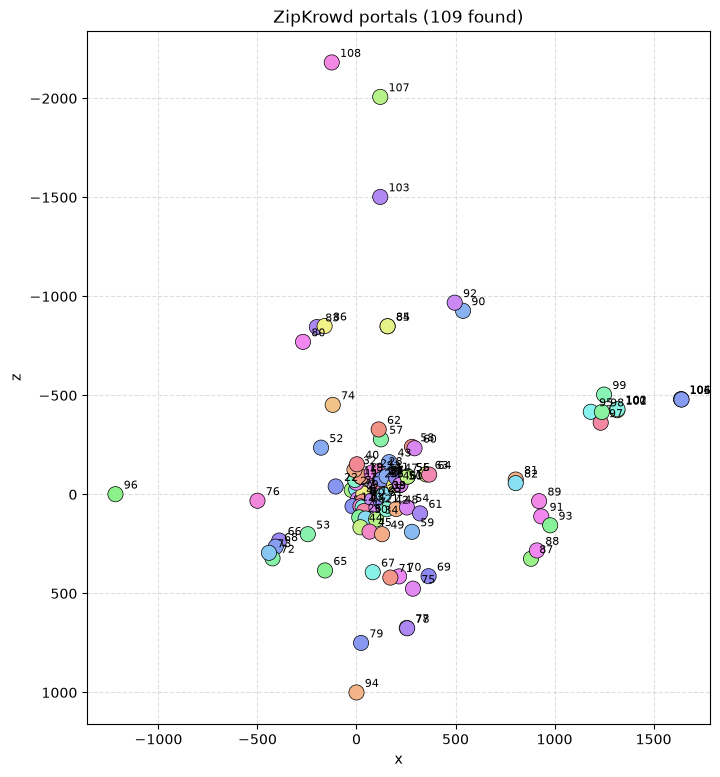

In [3]:
with OUTPUT_PATH.open(encoding='utf-8') as file:
    data = json.load(file)

stations = data['stations']
xs = [s['x'] for s in stations]
zs = [s['z'] for s in stations]
colors = [s['color'] for s in stations]

fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(xs, zs, c=colors, s=120, edgecolors='black', linewidths=0.5, zorder=2)
for station in stations:
    ax.annotate(
        station['name'],
        (station['x'], station['z']),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=8,
    )

ax.set_title(f'ZipKrowd portals ({len(stations)} found)')
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_aspect('equal')
ax.invert_yaxis()  # match Minecraft maps: +Z points south (down)
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Teleport command iterator

In [4]:
def tp_commands(path: Path = OUTPUT_PATH) -> Iterator[str]:
    with open(path, encoding='utf-8') as file:
        stations = json.load(file)['stations']
    for station in stations:
        yield f'/tp @p {station["x"]} {station["y"]} {station["z"]}'


commands = tp_commands()

In [5]:
# Trigger this cell multiple times
print(next(commands))

/tp @p 5 65 2
